Evaluation of NicheNet’s ligand-target predictions
================

This notebook shows how the ligand-target predictions of NicheNet were
evaluated. For validation, we collected transcriptome data of cells
before and after they were treated by one or two ligands in culture.
Using these ligand treatment datasets for validation has the advantage
that observed gene expression changes can be directly attributed to the
addition of the ligand(s). Hence, differentially expressed genes can be
considered as a gold standard of target genes of a particular ligand.

In [1]:
from nichenetpy.evaluation import (
    convert_expression_settings_evaluation,
    convert_settings_ligand_prediction,
    get_single_ligand_importances,
    evaluate_single_importances_ligand_prediction
)

from seaborn import violinplot
from itertools import chain

import os
import requests
import json
import pickle
import pandas as pd

In [2]:
data_path = os.path.normpath("./tutorial_files/model_evaluation")
if not os.path.exists(data_path):
    os.makedirs(data_path)
for filename in (
    #"cytosig_settings.json",
    "expression_settings_validation.json"
):
    file_path = os.path.join(data_path, filename)
    if not os.path.exists(file_path):
        res = requests.get(f"https://zenodo.org/records/15228527/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(res.content)
filename = "nichenet_human.pkl"
file_path = os.path.join("./tutorial_files", filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/14887637/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)

### Example: transcriptional response prediction evaluation

First, we will demonstrate how to evaluate the transcriptional response
(i.e. target gene prediction) performance for all ligand treatment
expression datasets. For this, we determine how well the model predicts
which genes are differentially expressed after treatment with a ligand.
Ideally, target genes with high regulatory potential scores for a
ligand, should be differentially expressed in response to that ligand.

For information of all collected ligand treatment datasets, see [Dataset
information](https://github.com/saeyslab/nichenetr/blob/master/vignettes/evaluation_datasets.xlsx)

For the sake of simplicity, we exclude in this vignette the
ligand-treatment datasets profiling the response to multiple ligands. To
see how to build a ligand-target model with target predictions for
multiple ligands at once: see [Construction of NicheNet’s
ligand-target model](model_construction.ipynb).

In [3]:
with open(os.path.join("./tutorial_files", "nichenet_human.pkl"), "rb") as file:
    model = pickle.loads(file.read())
predictor = model["predictor"]

Step 1: convert expression datasets to the required format to perform target gene prediction

In [4]:
with open(os.path.join(data_path, "expression_settings_validation.json"), "rb") as file:
    expression_settings_validation = json.loads(file.read())
settings = {
    v["name"]: convert_expression_settings_evaluation(v)
    for v in expression_settings_validation.values()
    if type(v["from"]) is str or len(v["from"]) == 1
}

Step 2: calculate the target gene prediction performances

In [5]:
performances = {
    k: predictor.evaluate_target_prediction(v["from"], v["response"])
    for k, v in settings.items()
}

Step 3: visualize the results: show different classification evaluation metrics

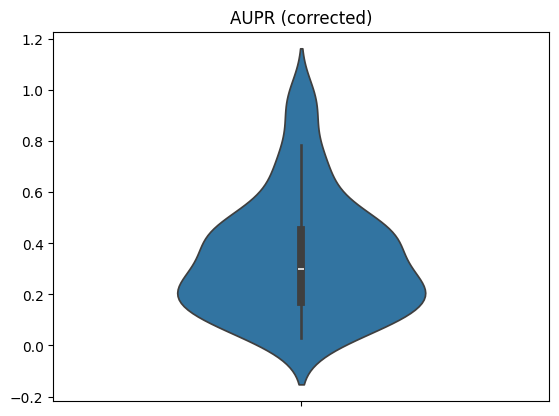

In [6]:
ax = violinplot(
    [e["aupr_corrected"] for e in performances.values()],
    width=0.5
)
_ = ax.set_title("AUPR (corrected)")

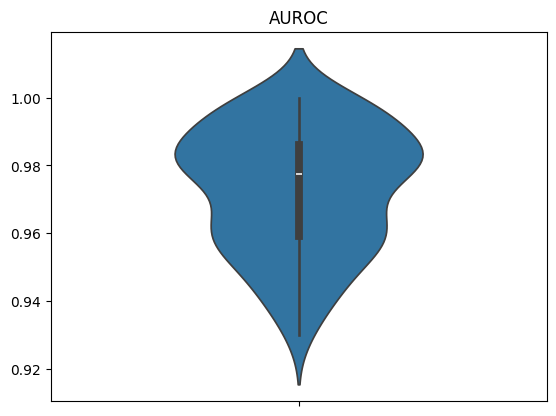

In [7]:
ax = violinplot(
    [e["auroc"] for e in performances.values()],
    width=0.5
)
_ = ax.set_title("AUROC")

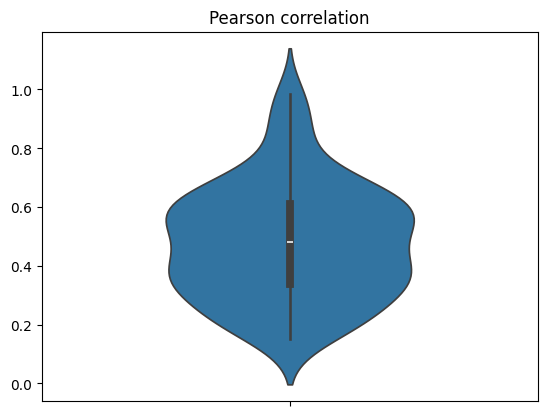

In [8]:
ax = violinplot(
    [e["pearson"] for e in performances.values()],
    width=0.5
)
_ = ax.set_title("Pearson correlation")

### Example: ligand activity prediction evaluation

Now we will show how to assess the accuracy of the model in predicting
whether cells were treated by a particular ligand or not. In other
words, we will evaluate how well NicheNet prioritizes active ligand(s),
given a set of differentially expressed genes. For this procedure, we
assume the following: the better a ligand predicts the transcriptional
response compared to other ligands, the more likely it is that this
ligand is active. Therefore, we first get ligand activity (or ligand
importance or feature importance) scores for all ligands on all
ligand-treatment expression datasets of which the true acive ligand is
known. Then we assess whether the truly active ligands indeed get higher
ligand activity scores as should be for a good ligand-target model.

A graphical summary of this procedure is visualized here below:

![](images/ligand_activity_prediction_workflow_new.png)

Step 1: convert expression datasets to the required format to perform ligand activity prediction

In [9]:
settings = {
    v["name"]: convert_expression_settings_evaluation(v)
    for v in expression_settings_validation.values()
    if type(v["from"]) is str or len(v["from"]) == 1
}
all_ligands = set(chain(*(
    [setting["from"]] if type(setting["from"]) is str else setting["from"]
    for setting in settings.values()
)))
settings_ligand_prediction = convert_settings_ligand_prediction(settings, all_ligands)

Step 2: calculate the ligand importances (these are classification evaluation metrics indicating how well a ligand can predict the observed DE genes in a specific ligand treatment dataset)

In [10]:
ligand_importances = get_single_ligand_importances(predictor, settings_ligand_prediction)
ligand_importances

,aupr,aupr_corrected,auroc,pearson,setting,test_ligand,true_ligand
0,0.017256,0.005015,0.600448,0.013117,bmp4_Bmp4,IL15,BMP4
1,0.017433,0.005193,0.622470,0.008454,bmp4_Bmp4,IL2,BMP4
2,0.022679,0.010439,0.648829,0.035175,bmp4_Bmp4,TGFA,BMP4
3,0.021471,0.009231,0.639494,0.027372,bmp4_Bmp4,CXCL12,BMP4
4,0.021638,0.009397,0.649511,0.037560,bmp4_Bmp4,IGF1,BMP4
...,...,...,...,...,...,...,...
4742,0.031134,0.024151,0.741408,0.073318,Cxcr4_Ackr3_timeseries,IL24,CXCL12
4743,0.021212,0.014229,0.696199,0.064504,Cxcr4_Ackr3_timeseries,IFNL3,CXCL12
4744,0.020428,0.013446,0.746241,0.059704,Cxcr4_Ackr3_timeseries,IFNG,CXCL12
4745,0.022329,0.015346,0.730440,0.042255,Cxcr4_Ackr3_timeseries,IL19,CXCL12


Step 3: evaluate how separate ligand importances can predict ligand activity

In [11]:
evaluation_ligand_prediction = pd.concat(
    evaluate_single_importances_ligand_prediction(ligand_importances, group)
    for group in set(ligand_importances["setting"])
)

Step 4: visualize the results: show different classification evaluation metrics

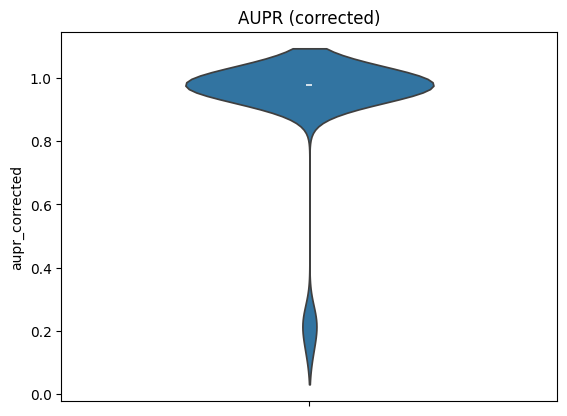

In [12]:
ax = violinplot(
    evaluation_ligand_prediction["aupr_corrected"],
    width=0.5
)
_ = ax.set_title("AUPR (corrected)")

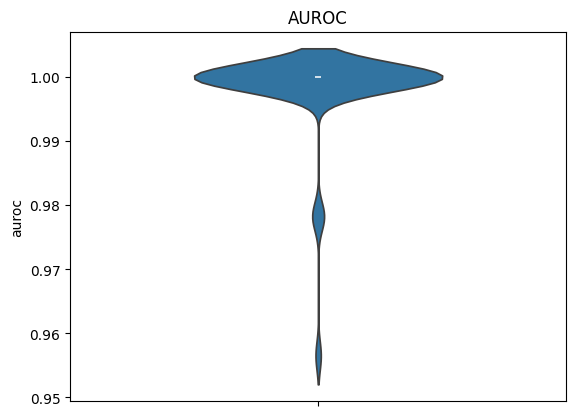

In [13]:
ax = violinplot(
    evaluation_ligand_prediction["auroc"],
    width=0.5
)
_ = ax.set_title("AUROC")

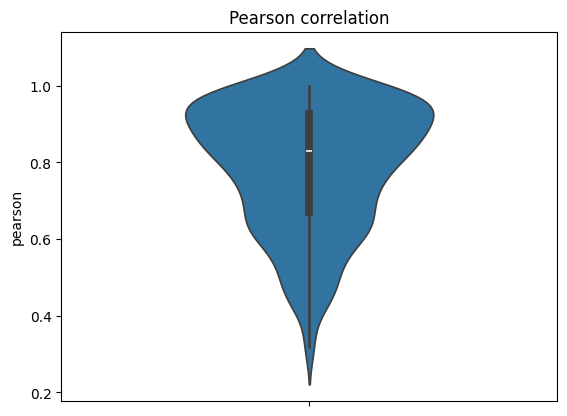

In [14]:
ax = violinplot(
    evaluation_ligand_prediction["pearson"],
    width=0.5
)
_ = ax.set_title("Pearson correlation")